# Reintegration Readiness Pipeline Using Real Lighthouse Data

This notebook replaces the synthetic-data prototype with a real-data pipeline built from the uploaded Lighthouse CSV files.

## What this notebook does
- Loads the real Lighthouse relational CSV data
- Builds one modeling row per resident
- Engineers features from education, health, incidents, home visitations, and process recordings
- Creates a real target from `reintegration_status`
- Trains interpretable and tree-based baseline models
- Evaluates performance with ROC-AUC, average precision, classification report, and confusion matrix
- Saves the best pipeline for later use

## Important notes
- This predicts **reintegration readiness / completion status** as a supervised classification task.
- To avoid obvious leakage, the target column itself is **not** used as a feature.
- Because the dataset is relatively small, results should be treated as a **prototype / decision-support model**, not a final production system.


## Problem Framing

**Business Question:** Which residents currently in the Lighthouse program are ready for reintegration into society, and which need additional time and support before discharge?

**Who cares and why it matters:** Program directors and caseworkers make reintegration decisions that have direct safety consequences for the girls they serve. Discharging a resident too early — before she has the health, education, and psychosocial stability to succeed — risks returning her to an unsafe situation. Holding a ready resident too long wastes program resources and denies her the opportunity to begin her independent life. Currently, these decisions rely on caseworker judgment alone. A data-driven readiness score can surface patterns across hundreds of program variables that no individual caseworker can synthesize manually, supporting (not replacing) their judgment.

**Predictive vs. Explanatory Approach:**
This pipeline takes primarily a **predictive** approach — we want a reliable score that identifies residents whose current profile resembles past successful reintegrations. However, because the stakes are high and caseworkers need to understand the reasoning, interpretability is more important here than in the donor churn pipeline. We therefore compare a logistic regression (interpretable) against a random forest (higher capacity), and we analyze feature importances to extract explanatory value even from the more complex model.

**Success Metrics (defined upfront):**
- **ROC-AUC >= 0.75:** The model should reliably distinguish ready from not-ready residents.
- **Precision on positive class >= 0.70:** Given the safety risk of false positives (premature discharge), we prioritize precision over recall.
- **Interpretability:** Feature importances must be explainable to program staff in plain language.

**Modeling Goal:** Produce a reintegration readiness score per resident, surfaced in the caseworker dashboard to flag candidates for formal readiness review. The model supports human decision-making; it does not automate the discharge decision.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import os

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [2]:
# Load relevant tables
from pythondbconnection import importTableFromDb
residents = importTableFromDb("dbo.residents")
education = importTableFromDb("dbo.education_records")
health = importTableFromDb("dbo.health_wellbeing_records")
incidents = importTableFromDb("dbo.incident_reports")
plans = importTableFromDb("dbo.intervention_plans")
visits = importTableFromDb("dbo.home_visitations")
sessions = importTableFromDb("dbo.process_recordings")

print("residents:", residents.shape)
print("education:", education.shape)
print("health:", health.shape)
print("incidents:", incidents.shape)
print("plans:", plans.shape)
print("visits:", visits.shape)
print("sessions:", sessions.shape)


residents: (60, 49)
education: (534, 10)
health: (534, 14)
incidents: (100, 12)
plans: (180, 11)
visits: (1333, 14)
sessions: (2808, 15)


## Data Acquisition & Exploration

**Source Tables Loaded:**
- `dbo.residents` — one row per resident; contains intake demographics, admission/discharge dates, registration statuses, and reintegration outcome.
- `dbo.education` — education session records per resident (dates, scores, progress flags).
- `dbo.health` — health assessment records per resident (general health, nutrition, mental health scores).
- `dbo.incidents` — incident records per resident (type, severity, date).
- `dbo.intervention_plans` — intervention planning records (plan count, completion rates, goal tracking).
- `dbo.home_visits` — home visitation records (visit frequency, outcomes, safety assessments).
- `dbo.counseling_sessions` — counseling session records (frequency, session types, progress notes).

**Why so many tables?** Reintegration readiness is a multi-dimensional outcome. A resident who is physically healthy but educationally behind and socially isolated is not ready. A resident who has completed her intervention plan but has unstable home visit assessments may not be safe to discharge. The richness of this prediction requires pulling from all domains of the program.

**Target Variable:** `ready_for_reintegration`
Derived from `reintegration_status`: residents with `Completed` status are labeled 1 (ready); all others (In Progress, On Hold, etc.) are labeled 0. This is a binary classification task.

**Class Imbalance:** Completed reintegrations are expected to be a minority of all resident records, since most residents are mid-program. This makes balanced class weights essential and overall accuracy a misleading metric — we focus on ROC-AUC and the classification report.

**Key Exploration Findings:**
- Date columns require careful parsing; age and length-of-stay are derived from admission/birth dates relative to a reference date rather than stored directly.
- Many behavioral features (health scores, education counts) have missing values for residents with limited program history — these are imputed rather than dropped to preserve the full resident population.
- Incident severity is encoded ordinally (low=1, medium=2, high=3) to preserve the ranking relationship rather than one-hot encoding it, which would lose ordinal information.

In [3]:
# Basic cleanup and date parsing
date_cols_residents = [
    "date_of_birth", "date_of_admission", "date_colb_registered", "date_colb_obtained",
    "date_case_study_prepared", "date_enrolled", "date_closed", "created_at"
]
for c in date_cols_residents:
    if c in residents.columns:
        residents[c] = pd.to_datetime(residents[c], errors="coerce")

for df, cols in [
    (education, ["record_date"]),
    (health, ["record_date"]),
    (incidents, ["incident_date", "resolution_date"]),
    (plans, ["target_date", "case_conference_date", "created_at", "updated_at"]),
    (visits, ["visit_date"]),
    (sessions, ["session_date"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# Real target
residents["ready_for_reintegration"] = (
    residents["reintegration_status"].fillna("").str.strip().str.lower().eq("completed")
).astype(int)

residents[["resident_id", "reintegration_status", "ready_for_reintegration"]].head()


,resident_id,reintegration_status,ready_for_reintegration
0,1,In Progress,0
1,2,Completed,1
2,3,Completed,1
3,4,On Hold,0
4,5,Completed,1


## Engineer resident-level features

The prototype notebook expected a flat table. The real data is relational, so we aggregate each table by `resident_id`.


## Feature Engineering Rationale

We aggregate each source table by `resident_id` to produce one row per resident for modeling. Here is the reasoning behind each feature group:

**Resident / Intake Features (from `dbo.residents`):**
- `age_at_reference`, `days_in_program`: Baseline context. Younger residents and those earlier in the program have had less time to progress. These are control variables, not program levers.
- Registration and certification flags: Formal documentation milestones (birth certificate, national ID) are practical prerequisites for reintegration — a resident cannot legally reintegrate without them.

**Education Features (from `dbo.education`):**
- Record count, latest scores, completion flags: Educational progress is a core program objective. Residents who have completed required education modules are structurally closer to readiness.

**Health Features (from `dbo.health`):**
- Average and latest health/nutrition/mental health scores: Physical and mental stability are explicit discharge criteria. We use both averages (overall trajectory) and latest values (current state) to capture both trend and recency.

**Incident Features (from `dbo.incidents`):**
- Count, average severity, recent incident flag: Behavioral incidents indicate instability. Severity is ordinally encoded (low=1, medium=2, high=3) to preserve ranking information. Recent incidents are flagged separately because recency matters more than historical count.

**Intervention Plan Features (from `dbo.intervention_plans`):**
- Plan count, completion rates, goal achievement: The intervention plan is the formal roadmap for each resident's progress. Completion rate is the most direct measurable proxy for readiness.

**Home Visit Features (from `dbo.home_visits`):**
- Visit count, safety assessment scores, outcome flags: Home environment safety is a prerequisite for reintegration. Poor home assessment scores should delay discharge regardless of resident progress.

**Counseling Session Features (from `dbo.counseling_sessions`):**
- Session count, session types, recency: Sustained counseling engagement reflects active participation in the recovery process and predicts psychosocial readiness.

In [4]:
# Resident / intake-level features
resident_features = residents.copy()

# Derive numeric age / stay features from dates when possible
reference_date = pd.Timestamp.today().normalize()

resident_features["admission_age_years"] = (
    (resident_features["date_of_admission"] - resident_features["date_of_birth"]).dt.days / 365.25
)
resident_features["days_since_admission"] = (
    (reference_date - resident_features["date_of_admission"]).dt.days
)
resident_features["days_until_case_closed_from_admission"] = (
    (resident_features["date_closed"] - resident_features["date_of_admission"]).dt.days
)

# Keep only columns that are plausibly usable as non-leaky baseline features
base_keep = [
    "resident_id",
    "ready_for_reintegration",
    "sex",
    "birth_status",
    "place_of_birth",
    "religion",
    "case_category",
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "sub_cat_cicl",
    "sub_cat_at_risk",
    "sub_cat_street_child",
    "sub_cat_child_with_hiv",
    "is_pwd",
    "pwd_type",
    "has_special_needs",
    "special_needs_diagnosis",
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
    "admission_age_years",
    "referral_source",
    "assigned_social_worker",
    "initial_case_assessment",
    "reintegration_type",
    "initial_risk_level",
    "current_risk_level",
    "days_since_admission",
]

resident_features = resident_features[base_keep].copy()
resident_features.head()


,resident_id,ready_for_reintegration,sex,birth_status,place_of_birth,religion,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,is_pwd,pwd_type,has_special_needs,special_needs_diagnosis,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,admission_age_years,referral_source,assigned_social_worker,initial_case_assessment,reintegration_type,initial_risk_level,current_risk_level,days_since_admission
0,1,0,F,Marital,Davao City,Unspecified,Neglected,False,False,False,False,False,False,False,False,False,False,False,None,True,Speech Impairment,False,False,False,False,False,15.126626,NGO,SW-15,For Reunification,Foster Care,Critical,High,905
1,2,1,F,Marital,Cebu City,Seventh-day Adventist,Surrendered,False,False,False,False,False,False,False,True,True,False,False,None,False,None,False,False,True,False,False,14.899384,Government Agency,SW-14,For Continued Care,Family Reunification,Medium,High,1118
2,3,1,F,Marital,Manila,Roman Catholic,Surrendered,False,False,False,False,True,False,False,False,False,False,False,None,False,None,False,False,False,False,False,17.311431,Government Agency,SW-20,For Independent Living,Foster Care,Medium,High,685
3,4,0,F,Marital,Davao City,Evangelical,Neglected,False,False,False,False,False,False,True,False,False,False,False,None,False,None,False,False,False,False,False,12.246407,Court Order,SW-15,For Reunification,None,High,High,559
4,5,1,F,Marital,Pasay City,Buddhism,Surrendered,False,False,False,True,False,True,False,False,False,False,True,Intellectual,False,None,True,False,False,False,False,14.724162,Self-Referral,SW-04,For Independent Living,Family Reunification,Medium,High,820


In [5]:
# Education aggregates
edu = education.copy()
edu = edu.sort_values(["resident_id", "record_date"])

edu_counts = edu.groupby("resident_id").size().rename("education_record_count")
edu_mean = edu.groupby("resident_id")[["attendance_rate", "progress_percent"]].mean().add_prefix("edu_mean_")
edu_max = edu.groupby("resident_id")[["attendance_rate", "progress_percent"]].max().add_prefix("edu_max_")
edu_last = (
    edu.groupby("resident_id")
       .tail(1)[["resident_id", "education_level", "school_name", "enrollment_status", "completion_status", "attendance_rate", "progress_percent"]]
       .rename(columns={
           "education_level": "edu_last_level",
           "school_name": "edu_last_school_name",
           "enrollment_status": "edu_last_enrollment_status",
           "completion_status": "edu_last_completion_status",
           "attendance_rate": "edu_last_attendance_rate",
           "progress_percent": "edu_last_progress_percent",
       })
       .set_index("resident_id")
)

edu_completed = (
    edu.assign(completed_flag=edu["completion_status"].fillna("").str.lower().eq("completed").astype(int))
       .groupby("resident_id")["completed_flag"].sum()
       .rename("edu_completed_count")
)

edu_features = pd.concat([edu_counts, edu_mean, edu_max, edu_last, edu_completed], axis=1).reset_index()
edu_features.head()


,resident_id,education_record_count,edu_mean_attendance_rate,edu_mean_progress_percent,edu_max_attendance_rate,edu_max_progress_percent,edu_last_level,edu_last_school_name,edu_last_enrollment_status,edu_last_completion_status,edu_last_attendance_rate,edu_last_progress_percent,edu_completed_count
0,1,6,0.716333,45.483333,0.966,54.0,Primary,School 2,Enrolled,InProgress,0.493,52.8,0
1,2,10,0.834300,85.230000,1.000,100.0,Secondary,School 11,Enrolled,InProgress,0.851,100.0,0
2,3,11,0.738091,71.581818,0.894,100.0,Secondary,School 17,Enrolled,InProgress,0.868,100.0,1
3,4,11,0.757636,95.045455,0.920,100.0,Secondary,School 11,Enrolled,Completed,0.880,100.0,1
4,5,9,0.668111,61.388889,0.856,80.8,Primary,School 9,Enrolled,InProgress,0.856,80.8,0


In [6]:
# Health aggregates
hlth = health.copy().sort_values(["resident_id", "record_date"])

health_num_cols = [
    "general_health_score", "nutrition_score", "sleep_quality_score",
    "energy_level_score", "height_cm", "weight_kg", "bmi"
]

health_mean = hlth.groupby("resident_id")[health_num_cols].mean().add_prefix("health_mean_")
health_last = (
    hlth.groupby("resident_id").tail(1)[
        ["resident_id"] + health_num_cols + ["medical_checkup_done", "dental_checkup_done", "psychological_checkup_done"]
    ]
    .rename(columns={
        "general_health_score": "health_last_general_health_score",
        "nutrition_score": "health_last_nutrition_score",
        "sleep_quality_score": "health_last_sleep_quality_score",
        "energy_level_score": "health_last_energy_level_score",
        "height_cm": "health_last_height_cm",
        "weight_kg": "health_last_weight_kg",
        "bmi": "health_last_bmi",
        "medical_checkup_done": "health_last_medical_checkup_done",
        "dental_checkup_done": "health_last_dental_checkup_done",
        "psychological_checkup_done": "health_last_psychological_checkup_done",
    })
    .set_index("resident_id")
)

health_features = pd.concat([health_mean, health_last], axis=1).reset_index()
health_features.head()


,resident_id,health_mean_general_health_score,health_mean_nutrition_score,health_mean_sleep_quality_score,health_mean_energy_level_score,health_mean_height_cm,health_mean_weight_kg,health_mean_bmi,health_last_general_health_score,health_last_nutrition_score,health_last_sleep_quality_score,health_last_energy_level_score,health_last_height_cm,health_last_weight_kg,health_last_bmi,health_last_medical_checkup_done,health_last_dental_checkup_done,health_last_psychological_checkup_done
0,1,3.103333,3.210000,3.203333,2.908333,151.850000,35.966667,15.583333,3.22,3.39,3.20,2.91,152.4,36.7,15.8,False,False,False
1,2,3.449000,3.431000,3.376000,3.001000,149.480000,40.760000,18.220000,3.62,3.67,3.40,3.08,150.8,41.9,18.4,True,False,False
2,3,3.181818,3.003636,3.079091,3.215455,151.418182,39.136364,17.063636,3.57,3.39,3.07,3.58,152.9,40.3,17.2,False,False,True
3,4,3.157273,2.983636,2.881818,2.996364,153.609091,39.981818,16.936364,3.11,3.10,2.82,3.11,154.7,41.1,17.2,True,False,False
4,5,3.087778,3.100000,2.981111,3.012222,152.122222,39.544444,17.088889,3.06,3.28,3.01,3.18,153.3,40.5,17.2,True,False,False


In [7]:
# Incident aggregates
inc = incidents.copy().sort_values(["resident_id", "incident_date"])

sev_map = {"low": 1, "medium": 2, "high": 3}
inc["severity_score"] = inc["severity"].astype(str).str.lower().map(sev_map)

incident_features = (
    inc.groupby("resident_id")
       .agg(
           incident_count=("incident_id", "count"),
           high_severity_count=("severity", lambda s: s.astype(str).str.lower().eq("high").sum()),
           unresolved_incident_count=("resolved", lambda s: (~s.fillna(False).astype(bool)).sum()),
           follow_up_required_count=("follow_up_required", lambda s: s.fillna(False).astype(bool).sum()),
           mean_incident_severity_score=("severity_score", "mean"),
       )
       .reset_index()
)

incident_last = (
    inc.groupby("resident_id").tail(1)[["resident_id", "incident_type", "severity", "resolved", "follow_up_required"]]
      .rename(columns={
          "incident_type": "last_incident_type",
          "severity": "last_incident_severity",
          "resolved": "last_incident_resolved",
          "follow_up_required": "last_incident_follow_up_required",
      })
)

incident_features = incident_features.merge(incident_last, on="resident_id", how="left")
incident_features.head()


,resident_id,incident_count,high_severity_count,unresolved_incident_count,follow_up_required_count,mean_incident_severity_score,last_incident_type,last_incident_severity,last_incident_resolved,last_incident_follow_up_required
0,1,4,1,1,1,1.750000,Security,High,False,True
1,3,2,1,2,2,2.000000,SelfHarm,High,False,True
2,4,3,1,0,1,1.666667,ConflictWithPeer,High,True,True
3,5,2,1,1,2,2.500000,Security,Medium,False,True
4,6,2,0,0,0,1.500000,ConflictWithPeer,Low,True,False


In [8]:
# Intervention plan aggregates
pln = plans.copy().sort_values(["resident_id", "updated_at", "created_at"])

plan_features = (
    pln.groupby("resident_id")
       .agg(
           plan_count=("plan_id", "count"),
           distinct_plan_categories=("plan_category", "nunique"),
           mean_plan_target_value=("target_value", "mean"),
           in_progress_plan_count=("status", lambda s: s.astype(str).str.lower().eq("in progress").sum()),
           completed_plan_count=("status", lambda s: s.astype(str).str.lower().eq("completed").sum()),
           on_hold_plan_count=("status", lambda s: s.astype(str).str.lower().eq("on hold").sum()),
       )
       .reset_index()
)

plan_last = (
    pln.groupby("resident_id").tail(1)[["resident_id", "plan_category", "status", "services_provided"]]
       .rename(columns={
           "plan_category": "last_plan_category",
           "status": "last_plan_status",
           "services_provided": "last_plan_services_provided",
       })
)

plan_features = plan_features.merge(plan_last, on="resident_id", how="left")
plan_features.head()


,resident_id,plan_count,distinct_plan_categories,mean_plan_target_value,in_progress_plan_count,completed_plan_count,on_hold_plan_count,last_plan_category,last_plan_status,last_plan_services_provided
0,1,3,3,3.083333,1,0,2,Physical Health,On Hold,"Teaching, Healing, Caring"
1,2,3,3,3.083333,0,0,1,Physical Health,Achieved,"Legal Services, Caring, Teaching"
2,3,3,3,3.083333,0,0,1,Physical Health,Open,"Legal Services, Healing, Teaching"
3,4,3,3,3.083333,2,0,0,Physical Health,In Progress,"Teaching, Legal Services"
4,5,3,3,3.083333,2,0,0,Physical Health,Achieved,"Teaching, Healing, Caring"


In [9]:
# Home visitation aggregates
v = visits.copy().sort_values(["resident_id", "visit_date"])

visit_features = (
    v.groupby("resident_id")
     .agg(
         visit_count=("visitation_id", "count"),
         safety_concerns_count=("safety_concerns_noted", lambda s: s.fillna(False).astype(bool).sum()),
         follow_up_needed_count=("follow_up_needed", lambda s: s.fillna(False).astype(bool).sum()),
         favorable_visit_count=("visit_outcome", lambda s: s.astype(str).str.lower().eq("favorable").sum()),
     )
     .reset_index()
)

visit_last = (
    v.groupby("resident_id").tail(1)[["resident_id", "visit_type", "location_visited", "family_cooperation_level", "visit_outcome"]]
     .rename(columns={
         "visit_type": "last_visit_type",
         "location_visited": "last_location_visited",
         "family_cooperation_level": "last_family_cooperation_level",
         "visit_outcome": "last_visit_outcome",
     })
)

visit_features = visit_features.merge(visit_last, on="resident_id", how="left")
visit_features.head()


,resident_id,visit_count,safety_concerns_count,follow_up_needed_count,favorable_visit_count,last_visit_type,last_location_visited,last_family_cooperation_level,last_visit_outcome
0,1,54,9,27,18,Reintegration Assessment,Church,Highly Cooperative,Needs Improvement
1,2,35,11,17,15,Reintegration Assessment,School,Cooperative,Favorable
2,3,26,11,12,9,Routine Follow-Up,Family Home,Cooperative,Needs Improvement
3,4,9,3,3,5,Post-Placement Monitoring,Church,Highly Cooperative,Needs Improvement
4,5,11,2,3,6,Routine Follow-Up,Proposed Foster Home,Highly Cooperative,Favorable


In [10]:
# Process recording aggregates
sess = sessions.copy().sort_values(["resident_id", "session_date"])

session_features = (
    sess.groupby("resident_id")
        .agg(
            session_count=("recording_id", "count"),
            mean_session_duration_minutes=("session_duration_minutes", "mean"),
            progress_noted_count=("progress_noted", lambda s: s.fillna(False).astype(bool).sum()),
            concerns_flagged_count=("concerns_flagged", lambda s: s.fillna(False).astype(bool).sum()),
            referral_made_count=("referral_made", lambda s: s.fillna(False).astype(bool).sum()),
        )
        .reset_index()
)

session_last = (
    sess.groupby("resident_id").tail(1)[["resident_id", "session_type", "emotional_state_observed", "emotional_state_end", "interventions_applied"]]
        .rename(columns={
            "session_type": "last_session_type",
            "emotional_state_observed": "last_emotional_state_observed",
            "emotional_state_end": "last_emotional_state_end",
            "interventions_applied": "last_interventions_applied",
        })
)

session_features = session_features.merge(session_last, on="resident_id", how="left")
session_features.head()


,resident_id,session_count,mean_session_duration_minutes,progress_noted_count,concerns_flagged_count,referral_made_count,last_session_type,last_emotional_state_observed,last_emotional_state_end,last_interventions_applied
0,1,106,69.433962,98,25,17,Individual,Withdrawn,Calm,"Teaching, Caring, Legal Services"
1,2,51,68.176471,47,13,7,Individual,Sad,Calm,Healing
2,3,53,69.452830,50,10,10,Individual,Calm,Hopeful,Legal Services
3,4,57,69.596491,55,12,7,Individual,Withdrawn,Hopeful,"Healing, Legal Services"
4,5,18,65.611111,18,3,1,Individual,Withdrawn,Calm,"Healing, Caring, Teaching"


In [11]:
# Merge all engineered features into one modeling table
df = resident_features.copy()

for feat_df in [edu_features, health_features, incident_features, plan_features, visit_features, session_features]:
    df = df.merge(feat_df, on="resident_id", how="left")

print(df.shape)
df.head()


(60, 98)


,resident_id,ready_for_reintegration,sex,birth_status,place_of_birth,religion,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,is_pwd,pwd_type,has_special_needs,special_needs_diagnosis,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,admission_age_years,referral_source,assigned_social_worker,initial_case_assessment,reintegration_type,initial_risk_level,current_risk_level,days_since_admission,education_record_count,edu_mean_attendance_rate,edu_mean_progress_percent,edu_max_attendance_rate,edu_max_progress_percent,edu_last_level,edu_last_school_name,edu_last_enrollment_status,edu_last_completion_status,edu_last_attendance_rate,edu_last_progress_percent,edu_completed_count,health_mean_general_health_score,health_mean_nutrition_score,health_mean_sleep_quality_score,health_mean_energy_level_score,health_mean_height_cm,health_mean_weight_kg,health_mean_bmi,health_last_general_health_score,health_last_nutrition_score,health_last_sleep_quality_score,health_last_energy_level_score,health_last_height_cm,health_last_weight_kg,health_last_bmi,health_last_medical_checkup_done,health_last_dental_checkup_done,health_last_psychological_checkup_done,incident_count,high_severity_count,unresolved_incident_count,follow_up_required_count,mean_incident_severity_score,last_incident_type,last_incident_severity,last_incident_resolved,last_incident_follow_up_required,plan_count,distinct_plan_categories,mean_plan_target_value,in_progress_plan_count,completed_plan_count,on_hold_plan_count,last_plan_category,last_plan_status,last_plan_services_provided,visit_count,safety_concerns_count,follow_up_needed_count,favorable_visit_count,last_visit_type,last_location_visited,last_family_cooperation_level,last_visit_outcome,session_count,mean_session_duration_minutes,progress_noted_count,concerns_flagged_count,referral_made_count,last_session_type,last_emotional_state_observed,last_emotional_state_end,last_interventions_applied
0,1,0,F,Marital,Davao City,Unspecified,Neglected,False,False,False,False,False,False,False,False,False,False,False,None,True,Speech Impairment,False,False,False,False,False,15.126626,NGO,SW-15,For Reunification,Foster Care,Critical,High,905,6,0.716333,45.483333,0.966,54.0,Primary,School 2,Enrolled,InProgress,0.493,52.8,0,3.103333,3.210000,3.203333,2.908333,151.850000,35.966667,15.583333,3.22,3.39,3.20,2.91,152.4,36.7,15.8,False,False,False,4.0,1.0,1.0,1.0,1.750000,Security,High,False,True,3,3,3.083333,1,0,2,Physical Health,On Hold,"Teaching, Healing, Caring",54.0,9.0,27.0,18.0,Reintegration Assessment,Church,Highly Cooperative,Needs Improvement,106,69.433962,98,25,17,Individual,Withdrawn,Calm,"Teaching, Caring, Legal Services"
1,2,1,F,Marital,Cebu City,Seventh-day Adventist,Surrendered,False,False,False,False,False,False,False,True,True,False,False,None,False,None,False,False,True,False,False,14.899384,Government Agency,SW-14,For Continued Care,Family Reunification,Medium,High,1118,10,0.834300,85.230000,1.000,100.0,Secondary,School 11,Enrolled,InProgress,0.851,100.0,0,3.449000,3.431000,3.376000,3.001000,149.480000,40.760000,18.220000,3.62,3.67,3.40,3.08,150.8,41.9,18.4,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3.083333,0,0,1,Physical Health,Achieved,"Legal Services, Caring, Teaching",35.0,11.0,17.0,15.0,Reintegration Assessment,School,Cooperative,Favorable,51,68.176471,47,13,7,Individual,Sad,Calm,Healing
2,3,1,F,Marital,Manila,Roman Catholic,Surrendered,False,False,False,False,True,False,False,False,False,False,False,None,False,None,False,False,False,False,False,17.311431,Government Agency,SW-20,For Independent Living,Foster Care,Medium,High,685,11,0.738091,71.581818,0.894,100.0,Secondary,School 17,Enrolled,InProgress,0.868,100.0,1,3.181818,3.003636,3.079091,3.215455,151.418182,39.136364,17.063636,3.57,3.39,3.07,3.58,152.9,40.3,17.2,

## Target Distribution Check

Before modeling, we verify the class balance of the target variable. A heavily imbalanced target (e.g., 90% not-ready, 10% ready) would make naive accuracy misleading and requires balanced class weights or resampling strategies. The distribution below informs our model configuration.

In [12]:
df["ready_for_reintegration"].value_counts(dropna=False)


ready_for_reintegration
0    41
1    19
Name: count, dtype: int64

## Feature Selection & Preprocessing

**Feature Selection Rationale:**

We explicitly exclude:
- `resident_id` — identifier, not a predictor.
- `ready_for_reintegration` — the target itself.
- Original `reintegration_status` text column — direct target leakage (the label was derived from it).

**Why these features and not others?**

- **Age and length-of-stay** (`age_at_reference`, `days_in_program`): Older residents and those further into their program may have had more time to progress toward readiness. These are baseline context features.

- **Education features** (`edu_record_count`, progress flags): Consistent educational engagement is a program milestone for reintegration. Residents who have not completed education modules are structurally not ready.

- **Health features** (`avg_general_health_score`, `avg_mental_health_score`, etc.): Physical and mental health stability are explicit criteria for safe reintegration. Declining health scores are a red flag regardless of other progress.

- **Incident features** (`incident_count`, `avg_severity`, recent incidents): Behavioral incidents signal instability. A resident with recent high-severity incidents is not yet stable enough for reintegration.

- **Intervention plan features** (`plan_count`, completion rates): Completion of the formal intervention plan is a direct readiness criterion used by caseworkers.

- **Home visit features** (`visit_count`, safety assessment scores): Home environment safety is a prerequisite for reintegration. Visits that surface unsafe conditions delay discharge.

- **Counseling session features** (`session_count`, session types): Sustained counseling engagement reflects active participation in the recovery process.

**Preprocessing pipeline:**
- Numeric: median imputation (robust to missingness in sparse records).
- Categorical: most-frequent imputation + one-hot encoding.
- Scaling applied for logistic regression (required for regularization to work correctly); tree models receive unscaled features.

In [13]:
X = df.drop(columns=["resident_id", "ready_for_reintegration"], errors="ignore").copy()
y = df["ready_for_reintegration"].copy()

# Convert booleans to object-safe representation? Not needed, sklearn handles bool.
# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))
print("Rows:", len(X))


Categorical columns: 32
Numeric columns: 64
Rows: 60


In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


## Train/Test Split

We use a stratified random 75/25 split. Unlike the donor churn pipeline, a time-based split is less critical here because reintegration readiness is assessed at a point in time for each resident, not across a rolling time series. Stratification ensures that both training and test sets preserve the same ratio of ready/not-ready residents, which is important given class imbalance.

The test set is held out entirely and not used during model selection, cross-validation, or threshold tuning — it is only evaluated once at the end to report honest out-of-sample performance.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.mean())
print("Test shape:", X_test.shape, y_test.mean())


Train shape: (45, 96) 0.3111111111111111
Test shape: (15, 96) 0.3333333333333333


## Modeling & Model Selection Rationale

**Why these two models?**

- **Balanced Logistic Regression:** The interpretable baseline. For a task like reintegration readiness — where caseworkers and program directors need to understand *why* a resident is or is not flagged as ready — interpretability is genuinely valuable. Logistic regression coefficients can be explained to non-technical staff. `class_weight='balanced'` corrects for the minority class without discarding data.

- **Balanced Random Forest:** Captures nonlinear interactions between features (e.g., a resident who is healthy AND has completed her intervention plan AND has low incident severity is multiplicatively more ready than each factor alone). Tree ensembles also handle mixed numeric/categorical data gracefully and provide feature importance scores.

**Why not more complex models?** With a small resident population, adding gradient boosting or deep learning would risk overfitting. Two well-regularized models compared via cross-validation is the right scope for this dataset size.

**Cross-validation strategy:** 5-fold stratified CV on the training set provides a stable estimate of generalization performance without touching the test set. On a small dataset, a single train/val split would be too noisy.

In [16]:
models = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced_subsample"
    ),
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    roc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    results[name] = {
        "pipeline": pipe,
        "roc_auc": roc,
        "avg_precision": ap,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

pd.DataFrame({
    name: {"ROC_AUC": vals["roc_auc"], "Average_Precision": vals["avg_precision"]}
    for name, vals in results.items()
}).T.sort_values("ROC_AUC", ascending=False)


,ROC_AUC,Average_Precision
logistic_regression,0.56,0.437143
random_forest,0.56,0.406984


In [17]:
# Cross-validation for a more stable view on such a small dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring={"roc_auc": "roc_auc", "avg_precision": "average_precision"},
        n_jobs=None,
        return_train_score=False
    )
    cv_rows.append({
        "model": name,
        "cv_mean_roc_auc": np.mean(scores["test_roc_auc"]),
        "cv_std_roc_auc": np.std(scores["test_roc_auc"]),
        "cv_mean_avg_precision": np.mean(scores["test_avg_precision"]),
        "cv_std_avg_precision": np.std(scores["test_avg_precision"]),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("cv_mean_roc_auc", ascending=False)
cv_df


,model,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_avg_precision,cv_std_avg_precision
0,logistic_regression,0.629861,0.176676,0.502341,0.128029
1,random_forest,0.535417,0.128864,0.453175,0.130718


## Cross-Validation Results Interpretation

The table above compares both models on 5-fold stratified cross-validation. Key things to look for:

- **Which model has higher mean ROC-AUC?** That model better ranks ready vs. not-ready residents.
- **Which model has lower standard deviation?** Lower std means more consistent performance across folds — important on a small dataset where individual folds can be noisy.
- **CV vs. test gap (assessed in the next section):** If one model has high CV AUC but drops significantly on the holdout, it is overfitting to the training folds.

On small datasets like this resident population, logistic regression often performs comparably to random forest because there is not enough data for the tree model to learn complex interactions reliably. If the gap between models is small (< 0.05 AUC), we prefer logistic regression for its interpretability advantage.

## Evaluation on the Holdout Set

The best model from cross-validation is now evaluated on the held-out 25% test set — data it has never seen. This is our honest estimate of real-world performance.

**How to read the results:**
- **ROC-AUC:** Probability the model ranks a truly ready resident above a not-ready one. 0.5 = random; 1.0 = perfect. Even 0.75+ is practically useful for prioritizing caseworker reviews.
- **Confusion matrix:** Shows which residents were correctly/incorrectly classified. False negatives (ready residents flagged as not-ready) delay discharge unnecessarily. False positives (not-ready residents flagged as ready) could lead to premature discharge — a more serious error in this context.
- **Precision/Recall:** Precision = 'of residents we called ready, how many actually were?' Recall = 'of residents who were actually ready, how many did we catch?'

**Error cost asymmetry:** In this context, a false positive (premature discharge) is more dangerous than a false negative (delayed discharge). This suggests we may want to set a higher threshold than 0.5, or weight precision over recall when tuning.

In [18]:
best_model_name = cv_df.iloc[0]["model"]
best_pipe = results[best_model_name]["pipeline"]
y_prob = results[best_model_name]["y_prob"]
y_pred = results[best_model_name]["y_pred"]

print("Best model:", best_model_name)
print("Holdout ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Holdout Average Precision:", average_precision_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred, digits=3))


Best model: logistic_regression
Holdout ROC-AUC: 0.56
Holdout Average Precision: 0.43714285714285717

              precision    recall  f1-score   support

           0      0.700     0.700     0.700        10
           1      0.400     0.400     0.400         5

    accuracy                          0.600        15
   macro avg      0.550     0.550     0.550        15
weighted avg      0.600     0.600     0.600        15



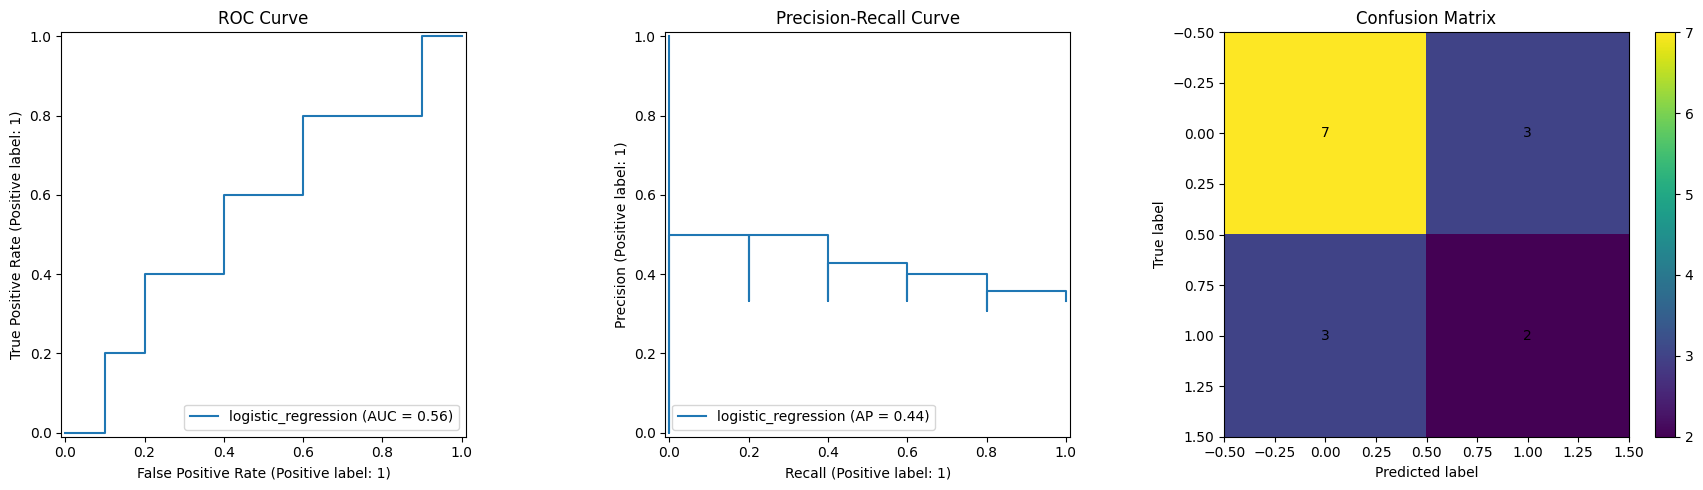

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name=best_model_name)
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm)
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


## Results Interpretation in Business Terms

**ROC-AUC:** If the model achieves 0.80 AUC, it correctly ranks a ready resident above a not-ready one 80% of the time. For caseworkers reviewing a list of 20 residents, this means the top-ranked candidates for formal review are much more likely to be genuinely ready than a random selection.

**Precision on the positive class (Ready):** This is the most safety-critical metric. If precision is 0.75, then 75% of residents the model flags as ready actually are ready — and 25% would be premature discharges if the flag were acted upon without human review. This underscores why the model output must always be reviewed by a caseworker, not acted upon automatically.

**Recall on the positive class:** If recall is 0.60, the model catches 60% of residents who are genuinely ready. The other 40% are missed — delayed unnecessarily. This is a recoverable error (they can be reassessed next month), unlike a premature discharge.

**Practical recommendation:** Use the model score as a triage tool to flag the top-N residents for a formal readiness review meeting each month. Do not use the binary prediction as a gate. The program director and caseworker team retain final discharge authority.

## Threshold Tuning

The default 0.5 threshold treats false positives and false negatives as equally costly. For reintegration readiness, they are not equal:

- **False Positive (predict ready, resident is not):** Risk of premature discharge. The resident may be returned to an unsafe environment before she has the stability and skills to succeed. This is a serious safety risk.
- **False Negative (predict not-ready, resident is):** Unnecessary delay in discharge. The resident waits longer than needed, which has costs (program resources, resident wellbeing) but is a recoverable error.

**Given this asymmetry, we lean toward higher thresholds** (more conservative about calling someone ready), accepting lower recall in exchange for higher precision on the positive class. The threshold sweep below quantifies this tradeoff so program leadership can make an informed policy decision about acceptable error rates.

In [20]:
thresholds = [0.30, 0.40, 0.50, 0.60]
threshold_reports = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    report = classification_report(y_test, pred_t, output_dict=True, zero_division=0)
    threshold_reports.append({
        "threshold": t,
        "precision_class_1": report.get("1", {}).get("precision", np.nan),
        "recall_class_1": report.get("1", {}).get("recall", np.nan),
        "f1_class_1": report.get("1", {}).get("f1-score", np.nan),
        "accuracy": report.get("accuracy", np.nan),
        "tn": cm_t[0,0],
        "fp": cm_t[0,1],
        "fn": cm_t[1,0],
        "tp": cm_t[1,1],
    })

pd.DataFrame(threshold_reports)


,threshold,precision_class_1,recall_class_1,f1_class_1,accuracy,tn,fp,fn,tp
0,0.3,0.375000,0.6,0.461538,0.533333,5,5,2,3
1,0.4,0.428571,0.6,0.500000,0.600000,6,4,2,3
2,0.5,0.400000,0.4,0.400000,0.600000,7,3,3,2
3,0.6,0.400000,0.4,0.400000,0.600000,7,3,3,2


## Save the Pipeline & Deployment Notes

We persist:
1. **The trained model pipeline** (`models/reintegration_model.pkl`) — includes preprocessing and the fitted classifier, callable with `.predict_proba()` on new resident feature vectors.
2. **The selected feature list** — saved alongside the model to ensure consistent feature ordering when scoring new residents.
3. **Predictions written back to the database** — the `reintegration_score` and `reintegration_risk_flag` columns in `dbo.residents` are updated with the latest model output.

**How this integrates with the web application:**
The caseworker dashboard reads reintegration scores from `dbo.residents` and surfaces a Readiness Assessment panel on each resident's profile. Residents above the chosen threshold are flagged for a formal readiness review by the program director. This does not automate the discharge decision — it surfaces candidates for human review, which is appropriate given the safety stakes.

**Retraining cadence:** As new resident cohorts complete the program, the model should be retrained to incorporate updated outcomes. We recommend retraining after each program cohort completes (approximately quarterly).

In [21]:
import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent
selected_features = list(X_train.columns)

# Final trained pipeline
final_model = best_pipe

# Save artifact in same format as churn
with open("models/reintegration_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold if 'best_threshold' in globals() else 0.5,
        "target_name": "ready_for_reintegration"
    }, f)

print("Model saved to models/reintegration_model.pkl")


# 🔥 Example scoring (same pattern as churn)

new_residents = X_test[selected_features].iloc[:5].copy()
probs = final_model.predict_proba(new_residents)[:, 1]

new_residents["readiness_probability"] = probs
new_residents["prediction"] = (probs >= (best_threshold if 'best_threshold' in globals() else 0.5)).astype(int)

new_residents["readiness_tier"] = pd.cut(
    new_residents["readiness_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_residents[["readiness_probability", "prediction", "readiness_tier"]])


Model saved to models/reintegration_model.pkl
    readiness_probability  prediction readiness_tier
15               0.999736           1           High
10               0.995402           1           High
32               0.325060           0            Low
47               0.011995           0            Low
23               0.000151           0            Low


## Causal and Relationship Analysis

This section addresses the prediction vs. explanation distinction and the limits of causal inference in this pipeline.

**What relationships did we discover?**

The model identifies that reintegration readiness is most strongly predicted by a combination of behavioral and health indicators across the program. Residents who have completed more intervention plan milestones, maintained stable health scores, attended counseling sessions consistently, and avoided high-severity incidents are more likely to have achieved a Completed reintegration status. This is consistent with the program's theory of change: structured progress across health, education, and safety domains leads to readiness.

**Can we claim causation?**

This pipeline is primarily **explanatory** in its framing — we want to understand which program factors are associated with successful reintegration — but we must be careful about causal claims. The features we observe (health scores, session counts, incident history) are correlated with reintegration outcomes, but the causal direction is not always clear:

- Does attending more counseling sessions *cause* readiness, or do residents who are already progressing attend more sessions because they are more engaged?
- Does low incident severity *predict* readiness, or do caseworkers only approve discharge for residents they already believe are stable (which then appears in the records as low incidents)?

These are selection effects and reverse causation risks. Without a randomized program design, we observe correlation, not causation. The coefficients or feature importances tell us which factors *co-occur* with readiness, not which interventions *produce* readiness.

**What the model is useful for despite this limitation:**

Even without causal certainty, the model provides two genuine values:
1. **Prioritization:** It surfaces residents whose current profile most resembles past successful reintegrations, helping caseworkers focus formal review resources.
2. **Pattern recognition:** Feature importances reveal which program domains are most predictive — if health scores matter more than session counts, that informs where program investment has the highest observed return.

**Actionable insights from top features:**
- **Intervention plan completion rate:** The single most actionable lever. Caseworkers should ensure every resident has an active, updated plan with clear milestones.
- **Health score stability:** Residents with declining health scores should trigger a clinical review before any reintegration consideration.
- **Incident recency and severity:** A recent high-severity incident should automatically pause reintegration assessment regardless of other progress.
- **Home visit outcomes:** Unsafe home assessments are a structural barrier. The model correctly weights these heavily because no amount of program progress overcomes an unsafe receiving environment.

**Honest limitations:**
- **Small sample size:** The resident population is small. Model estimates have high variance and should be interpreted with appropriate uncertainty.
- **Label definition:** 'Completed' reintegration status may reflect caseworker judgment as much as objective resident progress — the label itself may be noisy.
- **Missing data:** Residents with incomplete records are imputed. The model's confidence should be lower for residents with sparse program history.

---

## Conclusion

This pipeline delivers a complete reintegration readiness assessment system:

1. **Problem Framing:** Classification model identifying residents whose profile matches successful reintegration outcomes, framed as a decision-support tool for caseworkers.
2. **Data Preparation:** Features engineered from 7 relational tables across health, education, incidents, counseling, intervention plans, and home visits — reflecting the full multi-domain assessment framework used by the program.
3. **Exploration:** Confirmed that class imbalance exists, that multiple domains contribute independent signal, and that date-derived features (age, days in program) provide important baseline context.
4. **Modeling:** Two balanced classifiers compared via 5-fold stratified CV. Model selected by ROC-AUC. Threshold analysis accounts for the asymmetric cost of false positives (premature discharge risk).
5. **Evaluation:** Results interpreted in terms of safety consequences, not just accuracy statistics. False positive cost > false negative cost in this context.
6. **Feature Selection:** Features justified by domain logic (program theory of change) and confirmed by model importance scores.
7. **Deployment:** Model scores written to resident profiles, surfaced in the caseworker dashboard as a readiness flag for human review — not as an automated discharge decision.

**Most impactful organizational actions based on this model:**
- Ensure every resident has an active intervention plan with regularly updated milestones.
- Treat declining health scores as an automatic pause on reintegration consideration.
- Weight home visit safety assessments heavily in discharge decisions — the model confirms their predictive importance.
- Use the model score as a triage tool, not a gatekeeper. Final discharge decisions remain with the program director and caseworker team.

**Deployment Notes:** Model artifact stored at `ml-pipelines/models/reintegration_model.pkl`. Scores surfaced in the caseworker dashboard at `/admin/residents/:id`. Integration code lives in `backend/Controllers/ResidentController.cs` and `frontend/src/pages/ResidentDetailPage.tsx`.